# 📈 نموذج التنبؤ بالمبيعات (Linear Regression)

هذا النوتبوك يشرح المشروع خطوة بخطوة:

1. تحميل البيانات من `sales_data.csv`
2. استكشاف البيانات
3. تقسيم تدريب / اختبار
4. توحيد المقاييس (Scaling)
5. تدريب الموديل
6. فهم الأوزان (وإرجاعها لقيمها الأصلية)
7. التقييم (MSE / MAE / R²) والرسومات
8. التحقق اليدوي من التوقع
9. حفظ الموديل وتحميله والتوقع على مدخلات جديدة

> شغّل الخلايا بالترتيب من الأعلى للأسفل.

## 1) الاستيراد والإعدادات

In [1]:
import os
import sys
import glob
import subprocess
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_PATH = "sales_data.csv"
FEATURES = ["advertising", "price", "discount", "customers", "day_of_week", "stock"]
TARGET = "sales"

print("Imports OK")

Imports OK


## 2) تحميل البيانات

البيانات في ملف منفصل `sales_data.csv`. لو الملف غير موجود نشغّل `generate_data.py` لتوليده.

In [2]:
if not os.path.exists(DATA_PATH):
    print("sales_data.csv غير موجود، جاري توليده...")
    subprocess.run([sys.executable, "generate_data.py"], check=True)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (50000, 7)


,advertising,price,discount,customers,day_of_week,stock,sales
0,1935.25,85.49,23.23,358,5,112,4688.14
1,4758.50,51.98,21.08,489,6,303,8189.67
2,3686.77,23.57,14.04,213,1,758,5133.85
3,3033.43,74.98,19.73,91,5,860,3633.67
4,864.49,44.77,14.60,401,6,811,4363.58


## 3) استكشاف البيانات

In [3]:
df.describe().round(2)

,advertising,price,discount,customers,day_of_week,stock,sales
count,50000.00,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00
mean,2544.43,52.51,20.07,258.84,4.0,509.12,4508.67
std,1413.19,27.39,11.56,137.93,2.0,285.32,1599.60
min,100.03,5.00,0.00,20.00,1.0,10.00,373.99
25%,1319.66,28.76,10.01,140.00,2.0,264.00,3357.52
50%,2544.57,52.72,20.12,258.00,4.0,510.00,4511.52
75%,3766.68,76.32,30.08,378.00,6.0,755.00,5653.32
max,4999.86,100.00,40.00,499.00,7.0,999.00,8676.29


In [4]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   advertising  50000 non-null  float64
 1   price        50000 non-null  float64
 2   discount     50000 non-null  float64
 3   customers    50000 non-null  int64  
 4   day_of_week  50000 non-null  int64  
 5   stock        50000 non-null  int64  
 6   sales        50000 non-null  float64
dtypes: float64(4), int64(3)
memory usage: 2.7 MB

Missing values per column:
advertising    0
price          0
discount       0
customers      0
day_of_week    0
stock          0
sales          0
dtype: int64


### الارتباط (Correlation)

يوضح قوة العلاقة الخطية بين كل عمود وبين `sales`.
القيمة قريبة من +1 تعني علاقة طردية قوية، وقريبة من −1 تعني علاقة عكسية قوية.

price         -0.047
day_of_week    0.033
stock          0.055
discount       0.115
customers      0.694
advertising    0.710
Name: sales, dtype: float64


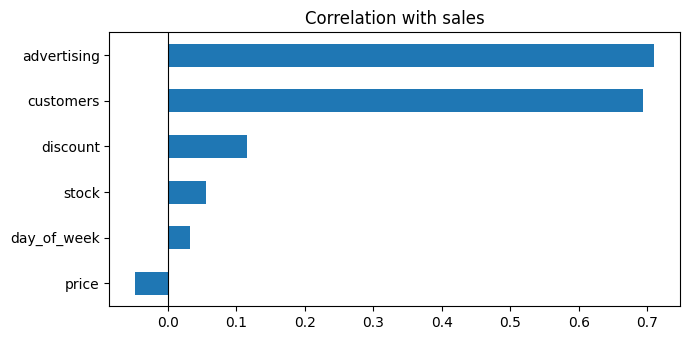

In [5]:
corr = df.corr()[TARGET].drop(TARGET).sort_values()
print(corr.round(3))

corr.plot(kind="barh", figsize=(7, 3.5), title="Correlation with sales")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

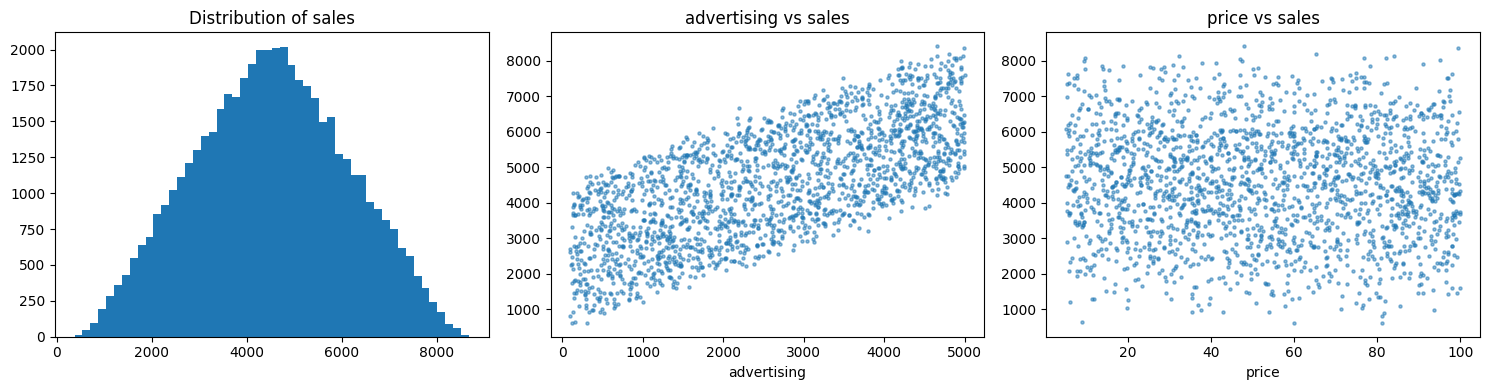

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df[TARGET], bins=50)
axes[0].set_title("Distribution of sales")

sample = df.sample(2000, random_state=1)
axes[1].scatter(sample["advertising"], sample[TARGET], s=5, alpha=0.5)
axes[1].set_title("advertising vs sales")
axes[1].set_xlabel("advertising")

axes[2].scatter(sample["price"], sample[TARGET], s=5, alpha=0.5)
axes[2].set_title("price vs sales")
axes[2].set_xlabel("price")

plt.tight_layout()
plt.show()

## 4) فصل المدخلات (X) عن المطلوب (y)

- `X`: الأعمدة الستة (المدخلات)
- `y`: عمود `sales` (اللي عايزين نتنبأ به)

In [7]:
X = df[FEATURES]
y = df[TARGET]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 6)
y shape: (50000,)


## 5) تقسيم تدريب / اختبار

- **80% تدريب**: الموديل يتعلم منها.
- **20% اختبار**: نحتفظ بها ولا يراها الموديل أثناء التدريب، لنقيس بها قدرته الحقيقية على التعميم.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (40000, 6)
Testing : (10000, 6)


## 6) التوحيد (StandardScaler)

المعادلة: `z = (x − mean) / std`

> **قاعدة مهمة:** `fit` على بيانات **التدريب فقط**، ثم `transform` على التدريب والاختبار.
> لو عملنا `fit` على الاختبار كمان، تتسرب معلومات منه للتدريب (Data Leakage).

In [9]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

check = pd.DataFrame({
    "mean (after)": X_train_s.mean(axis=0).round(4),
    "std (after)": X_train_s.std(axis=0).round(4),
}, index=FEATURES)
check

,mean (after),std (after)
advertising,-0.0,1.0
price,-0.0,1.0
discount,-0.0,1.0
customers,0.0,1.0
day_of_week,-0.0,1.0
stock,-0.0,1.0


## 7) تدريب الموديل

الموديل يفترض: `ŷ = w1·x1 + ... + w6·x6 + b`
و`fit()` يبحث عن أفضل `w` و`b` تُقلّل MSE.

In [10]:
model = LinearRegression()
model.fit(X_train_s, y_train)
print("Model trained successfully!")

weights_scaled = pd.Series(model.coef_, index=FEATURES)
print("\nWeights (on scaled features):")
print(weights_scaled.round(4))
print("\nBias:", round(model.intercept_, 4))

Model trained successfully!

Weights (on scaled features):
advertising    1130.1197
price           -68.3361
discount        173.2636
customers      1102.9467
day_of_week      40.1373
stock            85.3785
dtype: float64

Bias: 4508.7039


### إرجاع الأوزان لقيمها الأصلية

الأوزان أعلاه تخص البيانات **بعد التوحيد**، فلا تقارن مباشرة مع (0.8 و−2.5 ...).
للرجوع للوحدات الأصلية:

```
w_original = w_scaled / std
b_original = b_scaled − Σ (w_scaled · mean / std)
```

ثم نقارنها بالقيم الحقيقية التي استخدمناها في `generate_data.py`.

In [11]:
w_orig = model.coef_ / scaler.scale_
b_orig = model.intercept_ - np.sum(model.coef_ * scaler.mean_ / scaler.scale_)

true_w = {"advertising": 0.8, "price": -2.5, "discount": 15,
          "customers": 8, "day_of_week": 20, "stock": 0.3}

comparison = pd.DataFrame({
    "true weight": pd.Series(true_w),
    "learned weight": pd.Series(w_orig, index=FEATURES),
})
comparison["difference"] = comparison["learned weight"] - comparison["true weight"]
print(comparison.round(4))
print("\nLearned bias (true bias = 0):", round(b_orig, 4))

             true weight  learned weight  difference
advertising          0.8          0.8002      0.0002
price               -2.5         -2.4974      0.0026
discount            15.0         15.0007      0.0007
customers            8.0          8.0000      0.0000
day_of_week         20.0         20.0407      0.0407
stock                0.3          0.2993     -0.0007

Learned bias (true bias = 0): -0.6156


## 8) التقييم على بيانات الاختبار

- **MSE**: متوسط مربع الخطأ (يعاقب الأخطاء الكبيرة بقوة)
- **MAE**: متوسط الخطأ المطلق (بنفس وحدة المبيعات)
- **R²**: نسبة التباين التي فسّرها الموديل (1.0 = مثالي)

In [12]:
y_pred = model.predict(X_test_s)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

# تحقق يدوي من MSE
manual_mse = ((y_test - y_pred) ** 2).mean()
print(f"\nManual MSE : {manual_mse:.4f}  (يجب أن يساوي MSE أعلاه)")

MSE : 2481.4425
MAE : 39.7998
R²  : 0.9990

Manual MSE : 2481.4425  (يجب أن يساوي MSE أعلاه)


### مقارنة أول 5 أمثلة

In [13]:
comp = pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": y_pred[:5],
})
comp["Error"] = comp["Actual"] - comp["Predicted"]
comp["Squared_Error"] = comp["Error"] ** 2
comp.round(2)

,Actual,Predicted,Error,Squared_Error
0,3540.50,3499.65,40.85,1668.45
1,4732.86,4692.46,40.40,1631.94
2,7922.91,7860.37,62.54,3910.75
3,5274.89,5329.46,-54.57,2977.92
4,6425.62,6460.69,-35.07,1230.03


### الرسومات التشخيصية

- **Actual vs Predicted**: كلما كانت النقاط أقرب للخط القطري كان الموديل أفضل.
- **Residuals**: الأخطاء يجب أن تتوزع حول الصفر بشكل عشوائي بلا نمط.

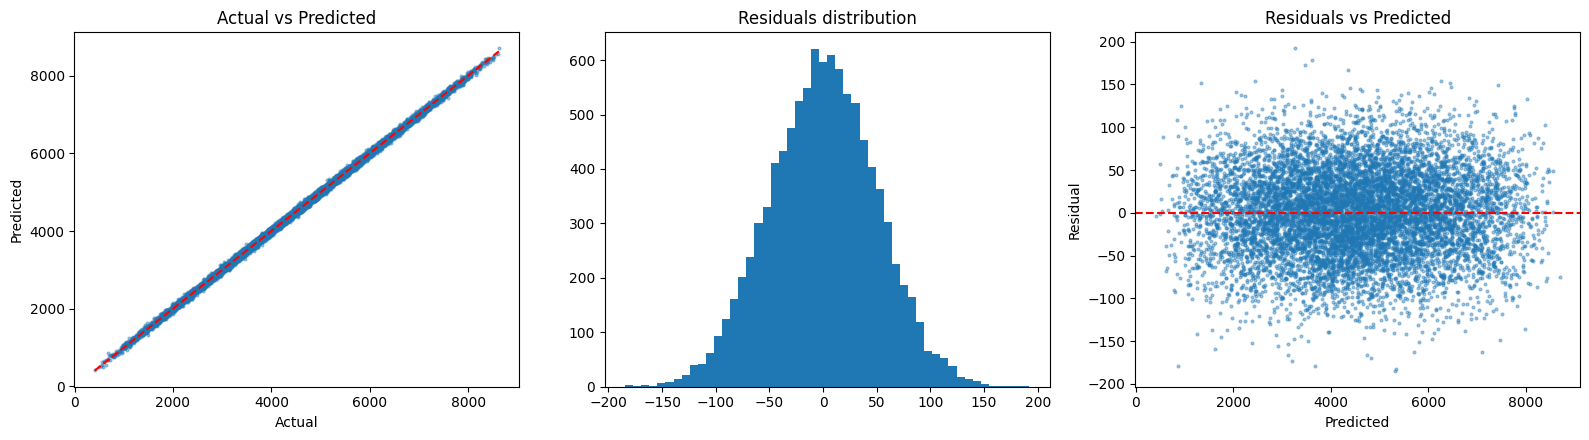

In [14]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, y_pred, s=4, alpha=0.4)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title("Actual vs Predicted")

axes[1].hist(residuals, bins=50)
axes[1].set_title("Residuals distribution")

axes[2].scatter(y_pred, residuals, s=4, alpha=0.4)
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

### Cross-Validation (اختياري)

نقسم البيانات 5 مرات بطرق مختلفة ونحسب R² في كل مرة، للتأكد أن النتيجة ما تعتمد على تقسيم واحد محظوظ.

In [15]:
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(StandardScaler(), LinearRegression())
scores = cross_val_score(pipe, X, y, cv=5, scoring="r2")
print("R² per fold:", scores.round(4))
print(f"Mean R²: {scores.mean():.4f}  (+/- {scores.std():.4f})")

R² per fold: [0.999  0.999  0.999  0.999  0.9991]
Mean R²: 0.9990  (+/- 0.0000)


## 9) التحقق اليدوي من عملية التوقع

نحسب التوقع بأنفسنا من الأوزان والـ bias (بعد تحويل المدخل بالـ scaler) ونقارنه بـ `model.predict`.

In [16]:
sample = X_test.iloc[[0]]
print(sample.T)

sample_scaled = scaler.transform(sample)[0]
manual = np.dot(sample_scaled, model.coef_) + model.intercept_
by_model = model.predict(scaler.transform(sample))[0]

print(f"\nManual prediction : {manual:.4f}")
print(f"Model prediction  : {by_model:.4f}")
print(f"Actual            : {y_test.iloc[0]:.4f}")

               33553
advertising  1470.66
price          97.56
discount       26.26
customers     233.00
day_of_week     1.00
stock         966.00

Manual prediction : 3499.6534
Model prediction  : 3499.6534
Actual            : 3540.5000


## 10) حفظ الموديل

نحفظ 3 أشياء داخل فولدر بنسخة (version) حسب الوقت:

- `best_model.pkl`: الموديل (الأوزان)
- `preprocessor.pkl`: الـ scaler (المتوسطات والانحرافات)
- `features.pkl`: أسماء الأعمدة بترتيبها

In [17]:
version = datetime.now().strftime("v1_%Y%m%d_%H%M%S")
model_dir = os.path.join("models", version)
os.makedirs(model_dir, exist_ok=True)

joblib.dump(model, os.path.join(model_dir, "best_model.pkl"))
joblib.dump(scaler, os.path.join(model_dir, "preprocessor.pkl"))
joblib.dump(FEATURES, os.path.join(model_dir, "features.pkl"))

print("✅ Saved in:", model_dir)
print(os.listdir(model_dir))

✅ Saved in: models/v1_20261001_235511
['best_model.pkl', 'features.pkl', 'preprocessor.pkl']


## 11) تحميل الموديل والتوقع على مدخلات جديدة

In [18]:
latest = sorted(glob.glob(os.path.join("models", "v1_*")))[-1]
loaded_model = joblib.load(os.path.join(latest, "best_model.pkl"))
loaded_scaler = joblib.load(os.path.join(latest, "preprocessor.pkl"))
loaded_features = joblib.load(os.path.join(latest, "features.pkl"))
print("Loaded:", latest)

def predict_sales(values: dict) -> float:
    row = pd.DataFrame([values])[loaded_features]
    return float(loaded_model.predict(loaded_scaler.transform(row))[0])

new_sale = {
    "advertising": 2500,
    "price": 30,
    "discount": 15,
    "customers": 200,
    "day_of_week": 5,
    "stock": 600,
}
print(f"Predicted Sales: {predict_sales(new_sale):,.2f}")

Loaded: models/v1_20261001_235511
Predicted Sales: 4,029.73


### تجربة تأثير عامل واحد

نغيّر ميزانية الإعلان فقط ونثبّت الباقي، لنشوف كيف تتغير المبيعات المتوقعة.

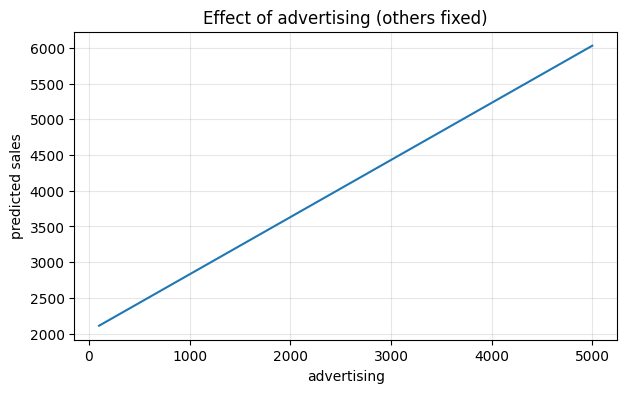

In [19]:
ads = np.linspace(100, 5000, 50)
preds = [predict_sales({**new_sale, "advertising": a}) for a in ads]

plt.figure(figsize=(7, 4))
plt.plot(ads, preds)
plt.xlabel("advertising")
plt.ylabel("predicted sales")
plt.title("Effect of advertising (others fixed)")
plt.grid(alpha=0.3)
plt.show()

## 12) الخلاصة

- البيانات في ملف منفصل (`sales_data.csv`) والكود يقرأها منه.
- الموديل تعلّم أوزاناً قريبة جداً من القيم الحقيقية، و R² ≈ 0.999.
- النتيجة العالية بسبب أن البيانات مولّدة من معادلة خطية. مع بيانات حقيقية توقّع أقل، وقد تحتاج موديلات غير خطية.
- الـ scaler لازم يُحفظ ويُستخدم مع الموديل دائماً.
- لا تثق بالتوقعات خارج نطاق القيم التي تدرّب عليها الموديل.